# DDoS Auswertung

## 0. Foreplay

### Notes:

instead of polars, the polars-lts-cpu package is used, to run on the old CPU's of the mobi8

### Imports

In [4]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

### Global parameters

In [5]:
SERVER_IP = "141.22.28.227"
PARQUET_FILE = "data/interim/ddos_1/batch_1_1000.parquet"
PARQUET_FOLDER = "data/processed/ddos_1/batch_1_1000/coap/"
PLOT_FOLDER = "plots/batch_1_1000/coap/"

### Read

In [6]:
lf = pl.scan_parquet(PARQUET_FILE).drop("dtls.record.content_type", "dtls.record.version", "dtls.handshake.type")

### Sample

In [7]:
df_sample = lf.limit(100000).collect().sample(5)
df_sample

frame.datetime,frame.len,frame.protocols,ip.src,ip.dst,ip.proto,ip.ttl,ipv6.src,ipv6.dst,ipv6.hlim,udp.srcport,udp.dstport,udp.length,tcp.srcport,tcp.dstport,tcp.len,coap.version,coap.type,coap.code,coap.mid,coap.token,coap.token_len,coap.opt.uri_path,coap.opt.uri_query,coap.opt.block_number,coap.opt.block_mflag,coap.opt.block_size,coap.opt.observe,coap.response_to,coap.response_in,coap.payload_length,source_file
datetime[μs],i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2025-08-13 15:51:50.412884,1514,"""eth:ethertype:ip:udp:dns""","""185.167.174.26""","""141.22.28.227""","""17""","""58""",null,null,null,"""53""","""19064""",3781,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.584228,471,"""eth:ethertype:ip:udp:data""","""179.251.45.75""","""141.22.28.227""","""17""","""50""",null,null,null,"""59076""","""8054""",437,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:49.922569,1514,"""eth:ethertype:ip:udp:cldap""","""15.235.50.67""","""141.22.28.227""","""17""","""113""",null,null,null,"""389""","""16736""",3092,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.277919,1514,"""eth:ethertype:ip:udp:dns""","""77.83.190.50""","""141.22.28.227""","""17""","""59""",null,null,null,"""53""","""59662""",3773,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:50.519939,271,"""eth:ethertype:ip:data""","""195.135.60.24""","""141.22.28.227""","""17""","""51""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"


## CoAP specific analysis

## Share of CoAP

In [8]:
lf_coap = lf.filter(
    pl.col("coap.version").is_not_null()
)
total_packets = lf.select(pl.len()).collect().item()
print(f"All pakets           : {total_packets:>12,}")
coap_packets = lf_coap.select(pl.len()).collect().item()
print(f"CoAP pakets          : {coap_packets:>12,}")
print(f"CoAP distrobution    : {coap_packets/total_packets:.2f}%")


All pakets           :  696,340,178
CoAP pakets          :   51,418,885
CoAP distrobution    : 0.07%


In [13]:
lf_coap_no_udp = lf_coap.filter(
    (pl.col("coap.version").is_not_null()) & (pl.col("ip.proto") != "17")
)


### IP Protocol Distribution

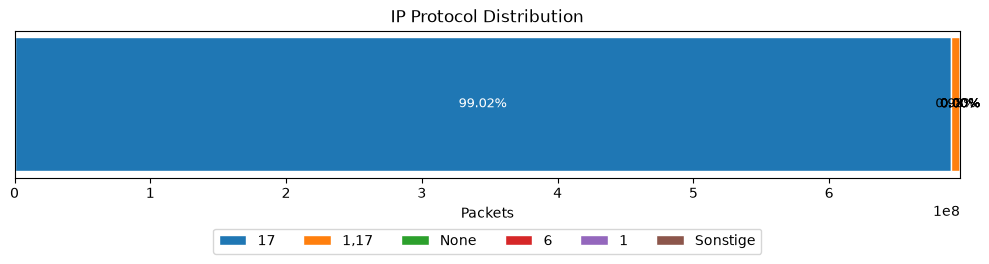

In [15]:
df = (
    lf.group_by("ip.proto")
    .agg(pl.len().alias("count"))
    .collect()
    .sort("count", descending=True)
)
labels = [str(x) for x in df["ip.proto"].to_list()]
values = df["count"].to_list()

# top_n_plus_other erwartet Spaltennamen, daher hier manuell mit String-Labels
total = sum(values)
top_labels, top_values = labels[:5], values[:5]
rest_sum = sum(values[5:])
if rest_sum > 0:
    top_labels.append("Sonstige")
    top_values.append(rest_sum)

del df

colors = plt.cm.tab10.colors[: len(top_labels)]

fig, ax = plt.subplots(figsize=(10, 3))

left = 0
for label, value, color in zip(top_labels, top_values, colors):
    pct = value / total * 100
    ax.barh(0, value, left=left, color=color, edgecolor="white", label=label)
    ax.text(
        left + value / 2, 0, f"{pct:.2f}%",
        ha="center", va="center", fontsize=9,
        color="white" if pct > 3 else "black",
    )
    left += value

ax.set_xlim(0, total)
ax.set_yticks([])
ax.set_xlabel("Packets")
ax.set_title("IP Protocol Distribution")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=len(top_labels))

plt.tight_layout()
plt.savefig(PLOT_FOLDER + "ip_proto_distr")
plt.show()
plt.close(fig)

### Mapping to Simple, Observe and Group Requests